In [29]:
from typing import Union, List

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

In [30]:
def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

def calcBalancedDownStep(
        spot_mult_up: float,
        discount_factor: float
) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

def create_spot_tree(
    spot: float,
    spot_mult_up: float,
    spot_mult_down: float,
    steps: int,
) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]

    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level

    return tree

def price_european_call(
    spot: float,
    spot_mult_up: float,
    discount_factor: float,
    K: float,
    steps: int,
) -> float:
    spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)
    spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)

    cv = [[float("nan")] * len(level) for level in spot_tree]

    # ❗ NO discount here
    for i, s in enumerate(spot_tree[-1]):
        cv[-1][i] = european_call_payoff(s, K)

    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            cv[step][i] = discount_factor * (
                0.5 * cv[step + 1][i] + 0.5 * cv[step + 1][i + 1]
            )

    return cv[0][0]

def black_scholes_eur_call(
    S0: float,
    K: float,
    r: float,
    sigma: float,
    T: float,
) -> float:
    # check conditions
    assert sigma > 0

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2 = d1 - sigma * T**0.5

    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Assignment
## Implement calibrator for Tree

* Background: In the Black--Scholes model volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability $= 0.5$ risk-neutral down step probability $= 0.5$) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.
* Task: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice option prices can be observed in the market, so it makes sense to assume it is given). Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (dont forget to scale the discount factor to keep interest rates flat); calibrate one step tree for various contracts (different expiries and strike levels, flat interest rate)). Make simple plots to illustrate results.
* Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

In [31]:
from scipy.optimize import brentq

def calibrate_up_step(
    target_price: float,
    spot: float,
    discount_factor: float,
    K: float,
    steps: int,
) -> float:
    """
    Finds the up-step multiplier u such that the binomial tree price
    matches the target_price.
    """

    def f(u):
        return price_european_call(
            spot=spot,
            spot_mult_up=u,
            discount_factor=discount_factor,
            K=K,
            steps=steps,
        ) - target_price

    u_low = 1.0001
    u_high = 2.0

    # biztosítjuk, hogy legyen gyök az intervallumban
    while f(u_low) * f(u_high) > 0:
        u_high *= 2
        if u_high > 100:
            raise ValueError("Could not bracket the root")

    return brentq(f, u_low, u_high)

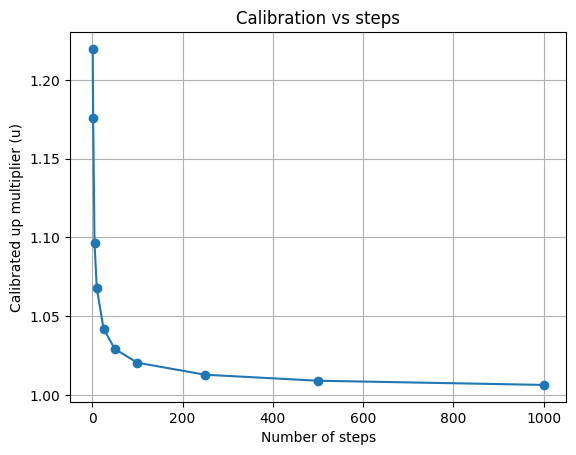

In [32]:
import matplotlib.pyplot as plt

S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0

# target price from Black-Scholes
target_price = black_scholes_eur_call(S0, K, r, sigma, T)

steps_list = [1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]
u_values = []

for steps in steps_list:
    discount_factor = np.exp(-r * T / steps)

    u = calibrate_up_step(
        target_price=target_price,
        spot=S0,
        discount_factor=discount_factor,
        K=K,
        steps=steps,
    )

    u_values.append(u)

plt.plot(steps_list, u_values, marker='o')
plt.xlabel("Number of steps")
plt.ylabel("Calibrated up multiplier (u)")
plt.title("Calibration vs steps")
plt.grid()
plt.show()

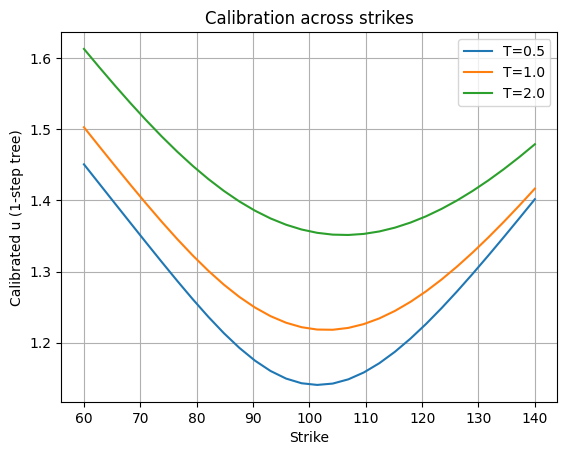

In [33]:
steps = 1
r = 0.05
S0 = 100
sigma = 0.2

Ks = np.linspace(60, 140, 30)
Ts = [0.5, 1.0, 2.0]

results = {}

for T in Ts:
    u_vals = []

    for K in Ks:
        target_price = black_scholes_eur_call(S0, K, r, sigma, T)
        discount_factor = np.exp(-r * T / steps)

        u = calibrate_up_step(
            target_price=target_price,
            spot=S0,
            discount_factor=discount_factor,
            K=K,
            steps=steps,
        )

        u_vals.append(u)

    plt.plot(Ks, u_vals, label=f"T={T}")

plt.xlabel("Strike")
plt.ylabel("Calibrated u (1-step tree)")
plt.title("Calibration across strikes")
plt.legend()
plt.grid()
plt.show()